# GeoClip Zero-Shot Baseline

Evaluate pretrained GeoClip on the MMlandmarks query set **without fine-tuning**.
The model embeds query ground images and gallery GPS coordinates into a shared
512-dim space, then retrieves the nearest GPS by cosine similarity.

**Gallery:** 17,557 train landmark GPS coordinates (closed-world).
**Queries:** 1,000 query landmarks (first ground image per landmark).
**Metric:** Accuracy @ {1, 25, 200, 750, 2500} km (Haversine distance).

## 1. Setup

In [5]:
from pathlib import Path
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import yaml

plt.rcParams.update({"figure.dpi": 120})

# Load config
with open("../../configs/geoclip_baseline.yaml") as f:
    cfg = yaml.safe_load(f)

DATA_ROOT = Path("../../") / cfg["data"]["root"]
assert DATA_ROOT.exists(), f"DATA_ROOT not found: {DATA_ROOT}"

device = cfg["inference"]["device"] if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")
print(f"Data root: {DATA_ROOT.resolve()}")

Device: cuda
Data root: /dtu/blackhole/02/137570/MML


## 2. Load Model

In [6]:
from mmgeo.geolocalizations.geoclip.geoclip_baseline import (
    GeoClipBaseline,
    load_gallery_coords,
    load_query_data,
    load_train_data,
)
from mmgeo.geolocalizations.geoclip.evaluate import (
    accuracy_at_thresholds,
    median_error,
    haversine,
)

baseline = GeoClipBaseline(device=device)

total_params = sum(p.numel() for p in baseline.model.parameters())
trainable_params = sum(p.numel() for p in baseline.model.parameters() if p.requires_grad)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Loading weights: 100%|██████████| 590/590 [00:00<00:00, 6769.93it/s]
CLIPModel LOAD REPORT from: openai/clip-vit-large-patch14
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


/zhome/57/e/219332/Multimodal-Geo-Spatial-Learning/.venv/lib/python3.11/site-packages/geoclip/model/location_encoder.py:57: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  sel

/zhome/57/e/219332/Multimodal-Geo-Spatial-Learning/.venv/lib/python3.11/site-packages/geoclip/model/GeoCLIP.py:37: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.image_e

Total parameters: 438,050,306
Trainable parameters: 10,432,257


## 3. Build GPS Gallery

In [7]:
gallery_coords = load_gallery_coords(
    DATA_ROOT, include_index=cfg["gallery"]["include_index"]
)
print(f"Gallery size: {len(gallery_coords):,} GPS points")
print(f"Lat range: [{gallery_coords[:, 0].min():.2f}, {gallery_coords[:, 0].max():.2f}]")
print(f"Lon range: [{gallery_coords[:, 1].min():.2f}, {gallery_coords[:, 1].max():.2f}]")

baseline.build_gallery(gallery_coords)
print("Gallery embeddings computed.")

train_image_paths, train_coords, train_landmark_ids = load_train_data(DATA_ROOT)
print(f"Train landmarks: {len(train_image_paths)}")

Gallery size: 17,557 GPS points
Lat range: [18.92, 49.00]
Lon range: [-156.00, -66.99]
Gallery embeddings computed.
Train landmarks: 17557


## 4. Load Query Data

In [8]:
image_paths, true_coords, landmark_ids = load_query_data(DATA_ROOT)
print(f"Query landmarks: {len(image_paths)}")
print(image_paths[0])


# Verify all image files exist
missing = [p for p in image_paths if not p.exists()]
if missing:
    print(f"WARNING: {len(missing)} images not found. First missing: {missing[0]}")
else:
    print("All query images found.")

Query landmarks: 1000
../../data/MML_Data/query/ground/9/b/9/9b9ee86db9dfe4f5.jpg
All query images found.


## 5. Run Inference

In [10]:
t0 = time.time()
pred_coords = baseline.predict_batch(
    image_paths, batch_size=cfg["inference"]["batch_size"]
)
train_pred_coords = baseline.predict_batch(
    train_image_paths, batch_size=cfg["inference"]["batch_size"]
)
elapsed = time.time() - t0
print(f"Inference complete: {len(pred_coords)} predictions in {elapsed:.1f}s")

Predicting:   0%|          | 0/16 [00:41<?, ?batch/s]


KeyboardInterrupt: 

## 6. Evaluate

In [ ]:
pred_lat, pred_lon = pred_coords[:, 0], pred_coords[:, 1]
true_lat, true_lon = true_coords[:, 0], true_coords[:, 1]

train_pred_lat, train_pred_lon = train_pred_coords[:, 0], train_pred_coords[:, 1]
train_true_lat, train_true_lon = train_coords[:, 0], train_coords[:, 1]

#stack them so they can be calculated in one go
pred_lats = np.concatenate([pred_lat, train_pred_lat])
pred_lons = np.concatenate([pred_lon, train_pred_lon])
true_lats = np.concatenate([true_lat, train_true_lat])
true_lons = np.concatenate([true_lon, train_true_lon])


thresholds = cfg["evaluation"]["thresholds_km"]
results = accuracy_at_thresholds(pred_lats, pred_lons, true_lats, true_lons, thresholds)
med_err = median_error(pred_lats, pred_lons, true_lats, true_lons)
distances = haversine(pred_lats, pred_lons, true_lats, true_lons)

results_df = pd.DataFrame(
    [{"Threshold (km)": t, "Accuracy (%)": f"{acc * 100:.2f}"} for t, acc in results.items()]
)
print(results_df.to_string(index=False))
print(f"\nMedian error: {med_err:.1f} km")
print(f"Mean error: {distances.mean():.1f} km")

 Threshold (km) Accuracy (%)
              1        11.30
             25        23.40
            200        43.10
            750        72.40
           2500        93.90

Median error: 279.8 km
Mean error: 626.4 km


## 7. Visualizations

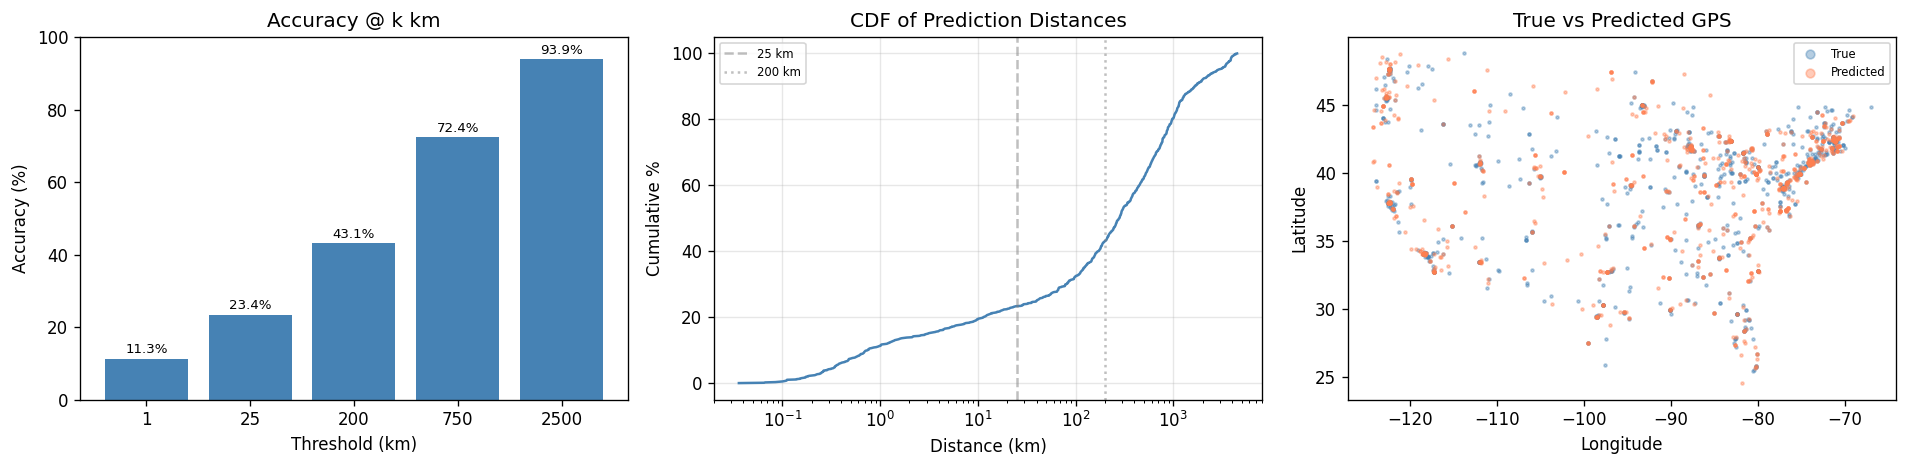

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# (a) Bar chart: accuracy at each threshold
ax = axes[0]
ax.bar([str(t) for t in thresholds], [results[t] * 100 for t in thresholds], color="steelblue")
ax.set_xlabel("Threshold (km)")
ax.set_ylabel("Accuracy (%)")
ax.set_title("Accuracy @ k km")
ax.set_ylim(0, 100)
for i, t in enumerate(thresholds):
    ax.text(i, results[t] * 100 + 1.5, f"{results[t]*100:.1f}%", ha="center", fontsize=8)

# (b) CDF of prediction distances
ax = axes[1]
sorted_dist = np.sort(distances)
cdf = np.arange(1, len(sorted_dist) + 1) / len(sorted_dist)
ax.plot(sorted_dist, cdf * 100, color="steelblue", linewidth=1.5)
ax.set_xscale("log")
ax.set_xlabel("Distance (km)")
ax.set_ylabel("Cumulative %")
ax.set_title("CDF of Prediction Distances")
ax.axvline(25, color="gray", linestyle="--", alpha=0.5, label="25 km")
ax.axvline(200, color="gray", linestyle=":", alpha=0.5, label="200 km")
ax.legend(fontsize=7)
ax.grid(True, alpha=0.3)

# (c) Scatter: true vs predicted GPS
ax = axes[2]
ax.scatter(true_lon, true_lat, s=3, alpha=0.4, label="True", color="steelblue")
ax.scatter(pred_lon, pred_lat, s=3, alpha=0.4, label="Predicted", color="coral")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("True vs Predicted GPS")
ax.legend(fontsize=7, markerscale=3)

plt.tight_layout()
plt.show()

## 8. Summary for Zero Shot

**Zero-shot GeoClip baseline** on MMlandmarks (1,000 query landmarks, 17,557 train GPS gallery):

| Threshold (km) | Accuracy (%) |
|---------------:|-------------:|
| 1              | 11.30        |
| 25             | 23.40        |
| 200            | 43.10        |
| 750            | 72.40        |
| 2500           | 93.90        |

- **Median error:** 279.8 km
- **Mean error:** 626.5 km
- **Inference time:** 1193.3 s (~20 min) on CPU

The pretrained GeoClip model was trained on 16M globally distributed Flickr images (MP-16).
Since our dataset is US-only, the model predicts globally distributed GPS even for US queries,
explaining the relatively high median error. Comparing to the papers results these results are a 3-7% worse than the original paper. It makes sense considering the dataset focuses on US-Landmarks only.

These results are the **lower bound** before fine-tuning.

**Next steps (Phase 2):** Fine-tune the Location Encoder and linear image head on the
MMlandmarks train split to adapt the model to our US-centric landmark distribution.